## Part I. K-Nearest Neighbor Algorithm

In [21]:
import numpy as np
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier

def KNN(X, Y):
    distances = metrics.pairwise.euclidean_distances(X, X)
    
    indices_voisins = np.argsort(distances, axis=1)
    
    indices_voisins = indices_voisins[:, 1]
    
    predictions = Y[indices_voisins]
    
    return predictions

In [25]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

def KNN2(X, Y):
    distances = euclidean_distances(X, X)
    
    indices_voisins = np.argsort(distances, axis=1)[:, 1] 
    
    labels = Y[indices_voisins]
    
    error = np.mean(labels != Y) 
    
    return error

In [23]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
Y = iris.target

error = KNN2(X, Y)

print(f"L'erreur de prédiction vaut : {error:.4f}")

L'erreur de prédiction vaut : 0.0400


In [24]:
from sklearn.datasets import load_iris
from sklearn.model_selection import LeaveOneOut
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import numpy as np

iris = load_iris()
X = iris.data
Y = iris.target

loo = LeaveOneOut()

for K in [1, 3, 5, 7, 9]:
    errors = []  
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]  
        Y_train, Y_test = Y[train_index], Y[test_index]
        
        knn = KNeighborsClassifier(n_neighbors=K)
        knn.fit(X_train, Y_train)  
        prediction = knn.predict(X_test)  
        
        errors.append(prediction != Y_test)
    
    error = np.mean(errors)
    print(f"Erreur de prédiction avec KNN de sklearn (K={K}, Leave-One-Out) : {error:.4f}")

Erreur de prédiction avec KNN de sklearn (K=1, Leave-One-Out) : 0.0400
Erreur de prédiction avec KNN de sklearn (K=3, Leave-One-Out) : 0.0400
Erreur de prédiction avec KNN de sklearn (K=5, Leave-One-Out) : 0.0333
Erreur de prédiction avec KNN de sklearn (K=7, Leave-One-Out) : 0.0333
Erreur de prédiction avec KNN de sklearn (K=9, Leave-One-Out) : 0.0333


L'erreur de prédiction avec la fonction KNN de sklearn pour K = 1 vaut : 0.04, c'est exactement la même erreur qu'on a eu avec notre propre fonction KNN.

In [16]:
import numpy as np
from sklearn import metrics
from scipy.stats import mode
from sklearn.datasets import load_iris

def KNN(X, Y, K):
    distances = metrics.pairwise.euclidean_distances(X, X)
    
    indices_voisins = np.argsort(distances, axis=1)[:, 1:K+1]
    
    voisins_labels = Y[indices_voisins]
    
    predictions = mode(voisins_labels, axis=1)[0].flatten()  # Mode retourne une matrice, on prend la première ligne
    
    error = np.mean(predictions != Y)
    
    return error

iris = load_iris()
X = iris.data
Y = iris.target

for K in [1, 3, 5, 9, 18, 19, 20, 25]:
    error = KNN(X, Y, K)
    print(f"Erreur de prédiction avec KNN (K={K}) : {error:.4f}")

Erreur de prédiction avec KNN (K=1) : 0.0400
Erreur de prédiction avec KNN (K=3) : 0.0400
Erreur de prédiction avec KNN (K=5) : 0.0333
Erreur de prédiction avec KNN (K=9) : 0.0333
Erreur de prédiction avec KNN (K=18) : 0.0267
Erreur de prédiction avec KNN (K=19) : 0.0200
Erreur de prédiction avec KNN (K=20) : 0.0267
Erreur de prédiction avec KNN (K=25) : 0.0333


- Lorsque K=1, l'algorithme est très sensible aux points aberrants (outliers), car il ne prend en compte qu'un seul voisin pour faire la prédiction.
- En augmentant K, l'algorithme devient plus robuste, car il prend en compte un plus grand nombre de voisins. Cela réduit l'impact des points aberrants, mais cela peut aussi réduire la précision si K devient trop grand, car les voisins lointains peuvent influencer la prédiction de manière non pertinente (à partir de K=20, l'erreur augmente)

## Part II. Other classifications algorithms

In [26]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
Y = iris.target

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

Erreur de prédiction pour SVM: 0.0000
Erreur de prédiction pour Naive Bayes: 0.0222
Erreur de prédiction pour Decision Tree: 0.0000


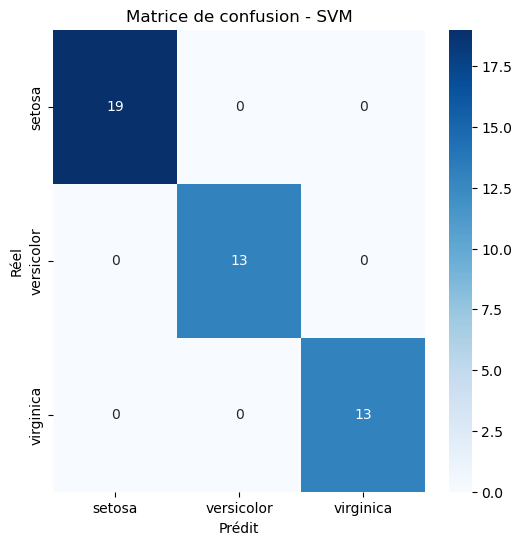

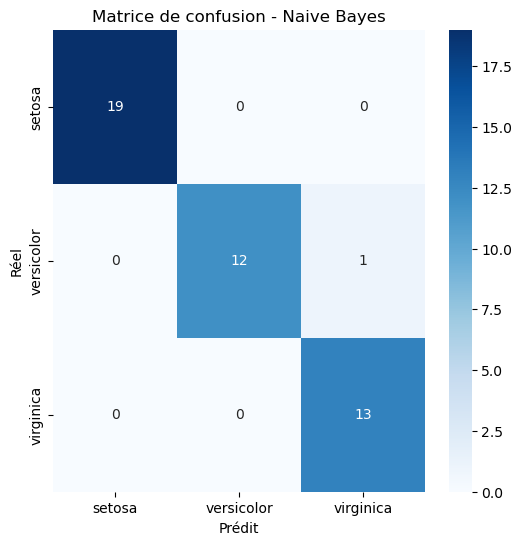

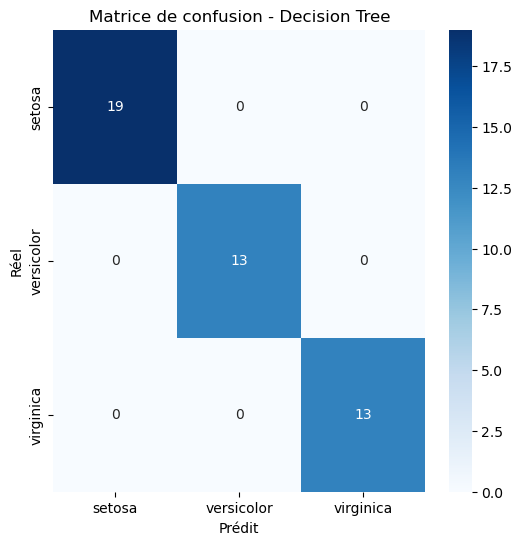

In [28]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Support Vector Machine (SVM)
svm = SVC(random_state=42)
svm.fit(X_train, Y_train)  
Y_pred_svm = svm.predict(X_test)  

# 2. Naive Bayesian Classifier
nb = GaussianNB()
nb.fit(X_train, Y_train) 
Y_pred_nb = nb.predict(X_test)  

# 3. Decision Trees
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, Y_train) 
Y_pred_dt = dt.predict(X_test)  

error_svm = 1 - accuracy_score(Y_test, Y_pred_svm)
error_nb = 1 - accuracy_score(Y_test, Y_pred_nb)
error_dt = 1 - accuracy_score(Y_test, Y_pred_dt)

print(f"Erreur de prédiction pour SVM: {error_svm:.4f}")
print(f"Erreur de prédiction pour Naive Bayes: {error_nb:.4f}")
print(f"Erreur de prédiction pour Decision Tree: {error_dt:.4f}")

mc_svm = confusion_matrix(Y_test, Y_pred_svm)
mc_nb = confusion_matrix(Y_test, Y_pred_nb)
mc_dt = confusion_matrix(Y_test, Y_pred_dt)

def plot_matrice_confusion(mc, nom_modele):
    plt.figure(figsize=(6,6))
    sns.heatmap(mc, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
    plt.title(f"Matrice de confusion - {nom_modele}")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()

plot_matrice_confusion(mc_svm, "SVM")
plot_matrice_confusion(mc_nb, "Naive Bayes")
plot_matrice_confusion(mc_dt, "Decision Tree")


## Analyse de la matrice de confusion

**SVM**  
Matrice de confusion :  
[[19  0  0]  
 [ 0 13  0]  
 [ 0  0 13]]  
→ Classification parfaite, aucune erreur.

**Naive Bayes**  
Matrice de confusion :  
[[19  0  0]  
 [ 0 12  1]  
 [ 0  0 13]]  
→ Une erreur : un échantillon de la classe "versicolor" a été classé comme "virginica.

**Decision Tree**  
Matrice de confusion :  
[[19  0  0]  
 [ 0 13  0]  
 [ 0  0 13]]  
→ Classification parfaite, aucune erreur.

**Conclusion**  
Les modèles SVM et Decision Tree réalisent une classification parfaite, tandis que Naive Bayes présente une légère confusion (un échantillon de la classe 1 mal classé en classe 2).  


**3. Find a solution to improve the obtained results, i.e. fit the parameters, etc.**

In [33]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]}

nb = GaussianNB()

grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, Y_train)

print("Meilleur paramètre pour Naive Bayes:", grid_search.best_params_)

best_nb = grid_search.best_estimator_
Y_pred_nb_optimized = best_nb.predict(X_test)
error_nb_optimized = 1 - accuracy_score(Y_test, Y_pred_nb_optimized)
print(f"Erreur de prédiction pour Naive Bayes optimisé: {error_nb_optimized:.4f}")


Meilleur paramètre pour Naive Bayes: {'var_smoothing': 1e-09}
Erreur de prédiction pour Naive Bayes optimisé: 0.0222


In [36]:
# Pour SVM
svm_tuned = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
svm_tuned.fit(X_train, Y_train)
Y_pred_svm_tuned = svm_tuned.predict(X_test)
erreur_svm_tuned = 1 - accuracy_score(Y_test, Y_pred_svm_tuned)
print(f"Erreur de prédiction optimisée pour SVM : {erreur_svm_tuned:.4f}")

# Pour Decision Tree
dt_tuned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=42)
dt_tuned.fit(X_train, Y_train)
Y_pred_dt_tuned = dt_tuned.predict(X_test)
erreur_dt_tuned = 1 - accuracy_score(Y_test, Y_pred_dt_tuned)
print(f"Erreur de prédiction optimisée pour Decision Tree : {erreur_dt_tuned:.4f}")


Erreur de prédiction optimisée pour SVM : 0.0000
Erreur de prédiction optimisée pour Decision Tree : 0.0000


Les résultats sont déjà parfaits pour svm et decision tree donc impossible de les améliorer.
Pour Naive Bayes, le score est déjà excellent (1 seule erreur) donc c'est compliqué de l'améliorer aussi